# Iris Flower Clustering (K-Means, k = 3)

**Week 3 Mini Project - Unsupervised Learning + Model Evaluation**

In this notebook we group Iris flowers into 3 clusters using the **K-Means** algorithm.

K-Means is an **unsupervised** algorithm, which means it never sees the real flower
species while it is learning. It only looks at the measurements (sepal and petal size)
and tries to put similar flowers into the same group.

At the end we compare the clusters K-Means found with the **true species labels**
to see how well the algorithm did.

**Steps in this notebook**
1. Load the Iris dataset
2. Explore the data
3. Scale the features
4. Apply K-Means clustering with `k = 3`
5. Visualize the clusters with scatter plots
6. Compare predicted clusters vs. true labels
7. Evaluate the clustering

## 1. Import the libraries

Each library has one job:

- `pandas` - load and handle the data as a table (DataFrame)
- `numpy` - numerical operations
- `matplotlib` / `seaborn` - drawing the plots
- `scikit-learn` - scaling, PCA and the K-Means algorithm

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             confusion_matrix, accuracy_score)

# Make the plots look nicer and keep results reproducible
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Iris dataset

The dataset is stored in `data/iris.csv`. It has 150 rows (flowers) and 5 columns:

| Column | Meaning |
|---|---|
| `sepal_length` | length of the sepal in cm |
| `sepal_width`  | width of the sepal in cm |
| `petal_length` | length of the petal in cm |
| `petal_width`  | width of the petal in cm |
| `species`      | the true flower type (setosa / versicolor / virginica) |

The `species` column is the **true label**. K-Means will **not** use it -
we keep it aside only to check our results at the end.

In [2]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv("data/iris.csv")

# Show the shape (rows, columns) and the first 5 rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Explore the data

A quick look before modelling: data types, missing values, basic statistics
and how many flowers belong to each species.

In [3]:
# Column names, data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# Check for missing values - clustering needs complete data
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [5]:
# Basic statistics (mean, std, min, max ...) of the four measurements
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# How many flowers of each species? (50 of each - a perfectly balanced dataset)
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Separate the features (X) from the true labels (y)

`X` = the 4 measurements the model is allowed to see.
`y_true` = the real species, kept only for the comparison in step 6.

In [7]:
# Features: the four numeric measurement columns
X = df.drop("species", axis=1)

# True labels: kept aside, NOT given to K-Means
y_true = df["species"]

print("Features used for clustering:", list(X.columns))
print("X shape:", X.shape)

Features used for clustering: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X shape: (150, 4)


## 4. Scale the features

K-Means measures the **distance** between points. If one column has much larger
numbers than another, that column would dominate the distance calculation.

`StandardScaler` rescales every column so it has a **mean of 0** and a
**standard deviation of 1**, giving all four measurements equal importance.

In [8]:
# Fit the scaler on X and transform the values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Put the scaled values back into a DataFrame just to look at them
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Mean of each scaled column (should be ~0):")
print(X_scaled_df.mean().round(3).to_string())
print("\nStandard deviation of each scaled column (should be ~1):")
print(X_scaled_df.std().round(3).to_string())

Mean of each scaled column (should be ~0):
sepal_length   -0.0
sepal_width    -0.0
petal_length   -0.0
petal_width    -0.0

Standard deviation of each scaled column (should be ~1):
sepal_length    1.003
sepal_width     1.003
petal_length    1.003
petal_width     1.003


## 5. Apply K-Means clustering with k = 3

How K-Means works, in simple words:

1. It places `k` random centre points (**centroids**) in the data.
2. Every flower is assigned to its **nearest** centroid.
3. Each centroid moves to the **average position** of the flowers assigned to it.
4. Steps 2 and 3 repeat until the centroids stop moving.

We choose `k = 3` because the task asks for 3 clusters
(and we know the Iris dataset contains 3 species).

In [9]:
# Create the K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)

# Train the model and get a cluster number (0, 1 or 2) for every flower
clusters = kmeans.fit_predict(X_scaled)

# Store the cluster labels in the DataFrame
df["cluster"] = clusters

print("Cluster labels found:", np.unique(clusters))
print("\nNumber of flowers in each cluster:")
print(df["cluster"].value_counts().sort_index().to_string())
df.head()

Cluster labels found: [0 1 2]

Number of flowers in each cluster:
cluster
0    53
1    50
2    47


,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


### The cluster centroids

The centroids are the "centre" of each cluster. Because we scaled the data,
we convert them back to the original centimetre units so they are easier to read.

In [10]:
# Convert the centroids from scaled values back to centimetres
centroids_cm = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(centroids_cm, columns=X.columns)
centroids_df.index.name = "cluster"
centroids_df.round(2)

,sepal_length,sepal_width,petal_length,petal_width
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


## 6. Visualize the clusters using scatter plots

### 6.1 Petal length vs. petal width

Petal measurements separate the Iris species very well, so this plot
gives a clear picture of the three clusters. The black `X` marks are the centroids.

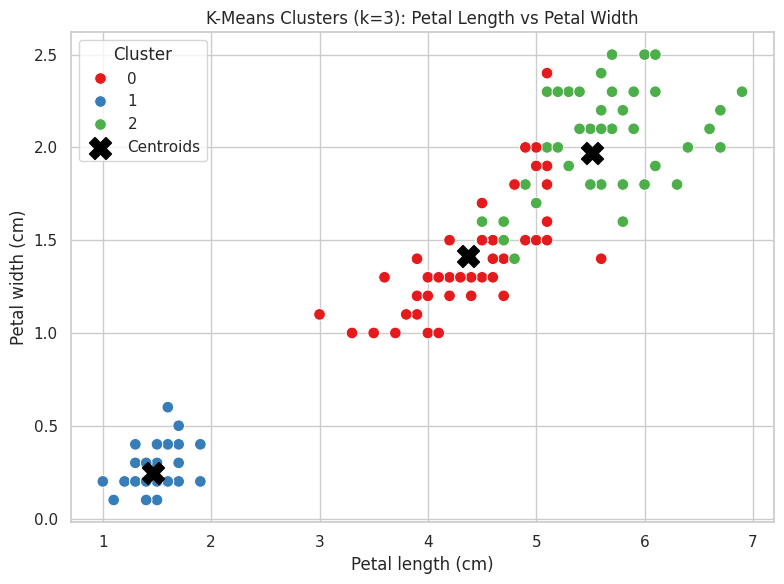

In [11]:
plt.figure(figsize=(8, 6))

# Draw each flower, coloured by the cluster K-Means assigned to it
sns.scatterplot(data=df, x="petal_length", y="petal_width",
                hue="cluster", palette="Set1", s=70)

# Draw the centroids on top
plt.scatter(centroids_df["petal_length"], centroids_df["petal_width"],
            c="black", marker="X", s=250, label="Centroids")

plt.title("K-Means Clusters (k=3): Petal Length vs Petal Width")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### 6.2 Predicted clusters vs. true species - side by side

The left plot shows the groups **K-Means found**.
The right plot shows the **real species**.
If the two plots look similar, the clustering worked well.

(The colours will not match between the plots, because cluster number `0`
is just a label - it has no connection to a particular species name.)

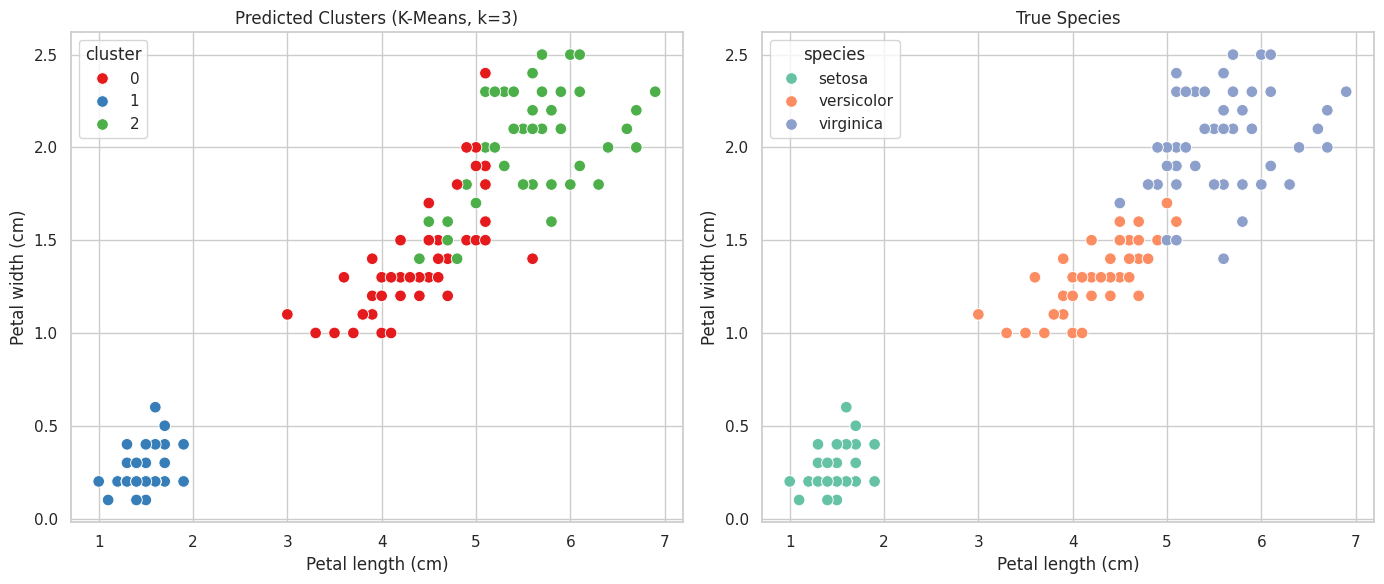

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters predicted by K-Means
sns.scatterplot(data=df, x="petal_length", y="petal_width",
                hue="cluster", palette="Set1", s=70, ax=axes[0])
axes[0].set_title("Predicted Clusters (K-Means, k=3)")
axes[0].set_xlabel("Petal length (cm)")
axes[0].set_ylabel("Petal width (cm)")

# Right: the true species labels
sns.scatterplot(data=df, x="petal_length", y="petal_width",
                hue="species", palette="Set2", s=70, ax=axes[1])
axes[1].set_title("True Species")
axes[1].set_xlabel("Petal length (cm)")
axes[1].set_ylabel("Petal width (cm)")

plt.tight_layout()
plt.show()

### 6.3 A 2D view of all four features using PCA

Our data has 4 features, but a scatter plot can only show 2 axes.
**PCA (Principal Component Analysis)** is a dimensionality-reduction technique:
it compresses the 4 columns into 2 new ones that keep as much of the
original information as possible. This lets us see *all* the features in one plot.

In [13]:
# Reduce the 4 scaled features down to 2 components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# How much of the original information the 2 components keep
explained = pca.explained_variance_ratio_
print(f"Information kept by component 1: {explained[0]:.1%}")
print(f"Information kept by component 2: {explained[1]:.1%}")
print(f"Total information kept: {explained.sum():.1%}")

# Store the two components for plotting
df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

Information kept by component 1: 73.0%
Information kept by component 2: 22.9%
Total information kept: 95.8%


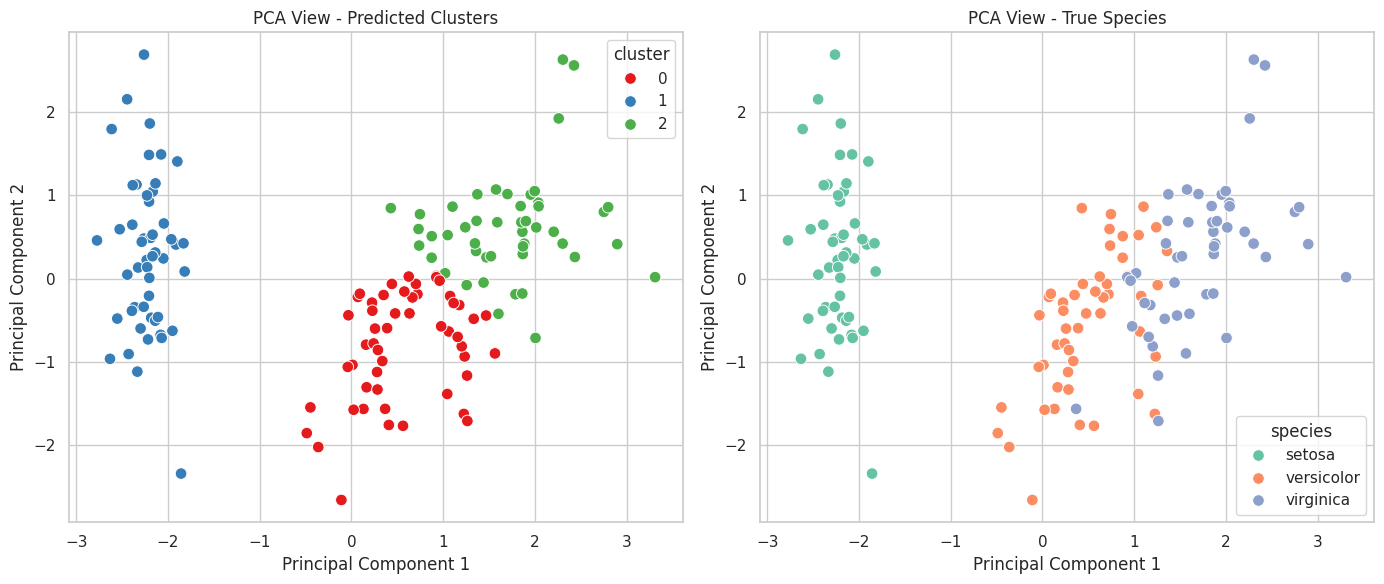

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: PCA view coloured by predicted cluster
sns.scatterplot(data=df, x="pca1", y="pca2",
                hue="cluster", palette="Set1", s=70, ax=axes[0])
axes[0].set_title("PCA View - Predicted Clusters")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

# Right: PCA view coloured by true species
sns.scatterplot(data=df, x="pca1", y="pca2",
                hue="species", palette="Set2", s=70, ax=axes[1])
axes[1].set_title("PCA View - True Species")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

## 7. Compare predicted clusters vs. true labels

K-Means gives us numbers (0, 1, 2), not species names. To compare them with
the real species we build a **cross-tabulation**: it counts how many flowers
of each species ended up in each cluster.

In [15]:
# Rows = cluster found by K-Means, Columns = true species
comparison = pd.crosstab(df["cluster"], df["species"],
                         rownames=["Cluster"], colnames=["True species"])
comparison

True species,setosa,versicolor,virginica
Cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


### Give each cluster a species name

Each cluster is matched to the species that appears **most often** inside it.
After this mapping we can count how many flowers were placed correctly.

In [16]:
# For every cluster, pick the species that appears most often in it
cluster_to_species = comparison.idxmax(axis=1).to_dict()
print("Cluster -> species mapping:")
for cluster_id, species in cluster_to_species.items():
    print(f"  Cluster {cluster_id} -> {species}")

# Translate the cluster numbers into species names
df["predicted_species"] = df["cluster"].map(cluster_to_species)

df[["sepal_length", "sepal_width", "petal_length", "petal_width",
    "species", "cluster", "predicted_species"]].head(10)

Cluster -> species mapping:
  Cluster 0 -> versicolor
  Cluster 1 -> setosa
  Cluster 2 -> virginica


,sepal_length,sepal_width,petal_length,petal_width,species,cluster,predicted_species
0,5.1,3.5,1.4,0.2,setosa,1,setosa
1,4.9,3.0,1.4,0.2,setosa,1,setosa
2,4.7,3.2,1.3,0.2,setosa,1,setosa
3,4.6,3.1,1.5,0.2,setosa,1,setosa
4,5.0,3.6,1.4,0.2,setosa,1,setosa
5,5.4,3.9,1.7,0.4,setosa,1,setosa
6,4.6,3.4,1.4,0.3,setosa,1,setosa
7,5.0,3.4,1.5,0.2,setosa,1,setosa
8,4.4,2.9,1.4,0.2,setosa,1,setosa
9,4.9,3.1,1.5,0.1,setosa,1,setosa


In [17]:
# How many flowers were placed in the right group?
correct = (df["predicted_species"] == df["species"]).sum()
total = len(df)
accuracy = accuracy_score(df["species"], df["predicted_species"])

print(f"Correctly grouped flowers: {correct} out of {total}")
print(f"Match with the true labels: {accuracy:.2%}")

Correctly grouped flowers: 125 out of 150
Match with the true labels: 83.33%


### Confusion matrix

The confusion matrix shows exactly **where** the mistakes happened.
Numbers on the diagonal are correct, everything else is a mismatch.

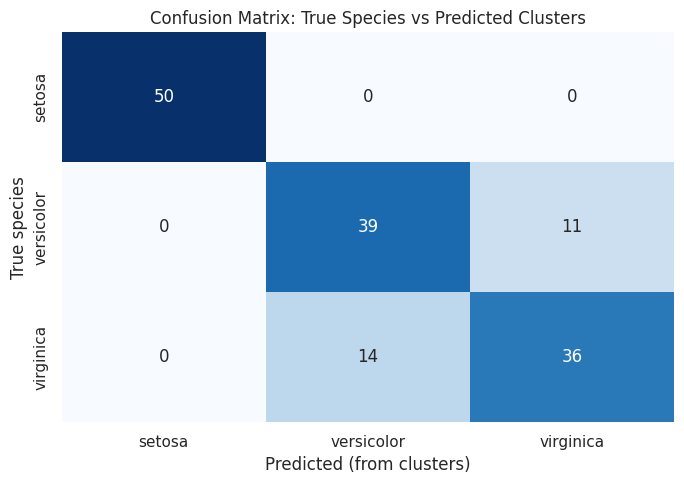

In [18]:
labels = ["setosa", "versicolor", "virginica"]
cm = confusion_matrix(df["species"], df["predicted_species"], labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)
plt.title("Confusion Matrix: True Species vs Predicted Clusters")
plt.xlabel("Predicted (from clusters)")
plt.ylabel("True species")
plt.tight_layout()
plt.show()

## 8. Evaluate the clustering

Two standard scores:

- **Silhouette Score** (-1 to 1): measures how tight and well-separated the
  clusters are. It does **not** use the true labels. Higher is better.
- **Adjusted Rand Index (ARI)** (-1 to 1): measures how much the clusters agree
  with the true labels. 1.0 means a perfect match, 0 means random grouping.

In [19]:
sil = silhouette_score(X_scaled, clusters)
ari = adjusted_rand_score(y_true, clusters)

print(f"Silhouette Score      : {sil:.3f}")
print(f"Adjusted Rand Index   : {ari:.3f}")
print(f"Accuracy vs true labels: {accuracy:.2%}")

Silhouette Score      : 0.460
Adjusted Rand Index   : 0.620
Accuracy vs true labels: 83.33%


## 9. Conclusion

- K-Means with `k = 3` was applied to the scaled Iris measurements **without
  ever seeing the species names**.
- **Setosa** was separated perfectly - it is clearly apart from the other two
  in every scatter plot.
- **Versicolor** and **Virginica** overlap a little, so a small number of
  flowers were placed in the wrong cluster. This is expected: these two species
  have genuinely similar petal and sepal sizes.
- Overall the clusters match the true species closely, which shows that the
  natural groups in the measurements correspond very well to the real flower species.

**Key takeaway:** even without labels, an unsupervised algorithm can rediscover
most of the structure that exists in the data.